<a href="https://colab.research.google.com/github/ldaniel-hm/eml_k_bandit/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos epsilon-greedy

*Description:* El estudio compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas diversas para cada algoritmo.

Basado en código inicial de Luis Daniel Hernández Molinero Email: ldaniel@um.es Date: 2025/01/29

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



## Preparación del entorno


In [1]:
#@title Copiar el repositorio.

#!git clone github.com/aalonsopuig/k_brazos_AAPGAG.git
#!cd eml_k_bandit/

In [2]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('src')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy
from arms import ArmNormal, ArmBernoulli, ArmBinomial, ArmBeta, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret


['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', '', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32\\lib', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan dos algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

Este código ejecuta múltiples simulaciones de un problema de bandido k-brazos pudiendo utilizarse distintos algoritmos, calcula las recompensas promedio y el porcentaje de selecciones óptimas a lo largo de los pasos de tiempo.

In [3]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Ejecuta un experimento de multi-armed bandit para evaluar diferentes algoritmos.

    Parámetros:
    bandit: Instancia del problema Bandit, que contiene las probabilidades de recompensa de cada brazo.
    algorithms: Lista de algoritmos de selección de brazos a comparar.
    steps: Número de pasos (iteraciones) que se ejecutarán por cada corrida.
    runs: Número de veces que se repetirá el experimento para obtener promedios.

    Devuelve:
    rewards: Matriz con las recompensas promedio obtenidas por cada algoritmo en cada paso.
    optimal_selections: Matriz con el porcentaje de veces que cada algoritmo seleccionó el brazo óptimo.
    """
    
    optimal_arm = bandit.optimal_arm  # Identifica el brazo con la mejor recompensa esperada

    rewards = np.zeros((len(algorithms), steps))  # Inicializa matriz para acumular recompensas
    optimal_selections = np.zeros((len(algorithms), steps))  # Inicializa matriz para contar selecciones óptimas

    np.random.seed(seed)  # Fija la semilla para reproducibilidad

    for run in range(runs):  # Itera por cada corrida del experimento
        current_bandit = Bandit(arms=bandit.arms)  # Crea una nueva instancia del bandit para cada corrida

        for algo in algorithms:
            algo.reset()  # Reinicia el estado de cada algoritmo

        for step in range(steps):  # Itera por cada paso dentro de una corrida
            for idx, algo in enumerate(algorithms):  # Itera por cada algoritmo
                chosen_arm = algo.select_arm()  # El algoritmo selecciona un brazo
                reward = current_bandit.pull_arm(chosen_arm)  # Se obtiene la recompensa al tirar de ese brazo
                algo.update(chosen_arm, reward)  # El algoritmo actualiza su estrategia con el nuevo dato

                rewards[idx, step] += reward  # Acumula la recompensa obtenida en este paso para este algoritmo

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1  # Incrementa el contador si el brazo elegido fue el óptimo

    rewards /= runs  # Calcula el promedio de recompensas por cada paso y algoritmo
    optimal_selections = (optimal_selections / runs) * 100  # Convierte las selecciones óptimas a porcentaje

    return rewards, optimal_selections  # Devuelve las matrices de recompensas y selecciones óptimas

## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [4]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

Aunque todo el estudio está basado en bandidos de **distribución Normal**, están implementadas también las **distribuciones Bernoulli, Binomial, y Beta**. Para usarlas en este experimento tan solo hay que quitar la almohadilla (#) de la que se desee ejecutar a continuación.

In [5]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
#bandit = Bandit(arms=ArmBernoulli.generate_arms(k))  # Crear un bandido con k brazos de distribución Bernoulli
#bandit = Bandit(arms=ArmBinomial.generate_arms(k))  # Crear un bandido con k brazos de distribución Binomial
#bandit = Bandit(arms=ArmBeta.generate_arms(k))  # Crear un bandido con k brazos de distribución Beta
print(bandit)

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)


In [6]:

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, algorithms, steps, runs)


Optimal arm: 8 with expected reward=9.56


## Visualización de los resultados

### Recompensa Promedio vs Pasos de Tiempo.
Muestra cómo evolucionan las recompensas promedio obtenidas por cada algoritmo a lo largo de los pasos de tiempo.

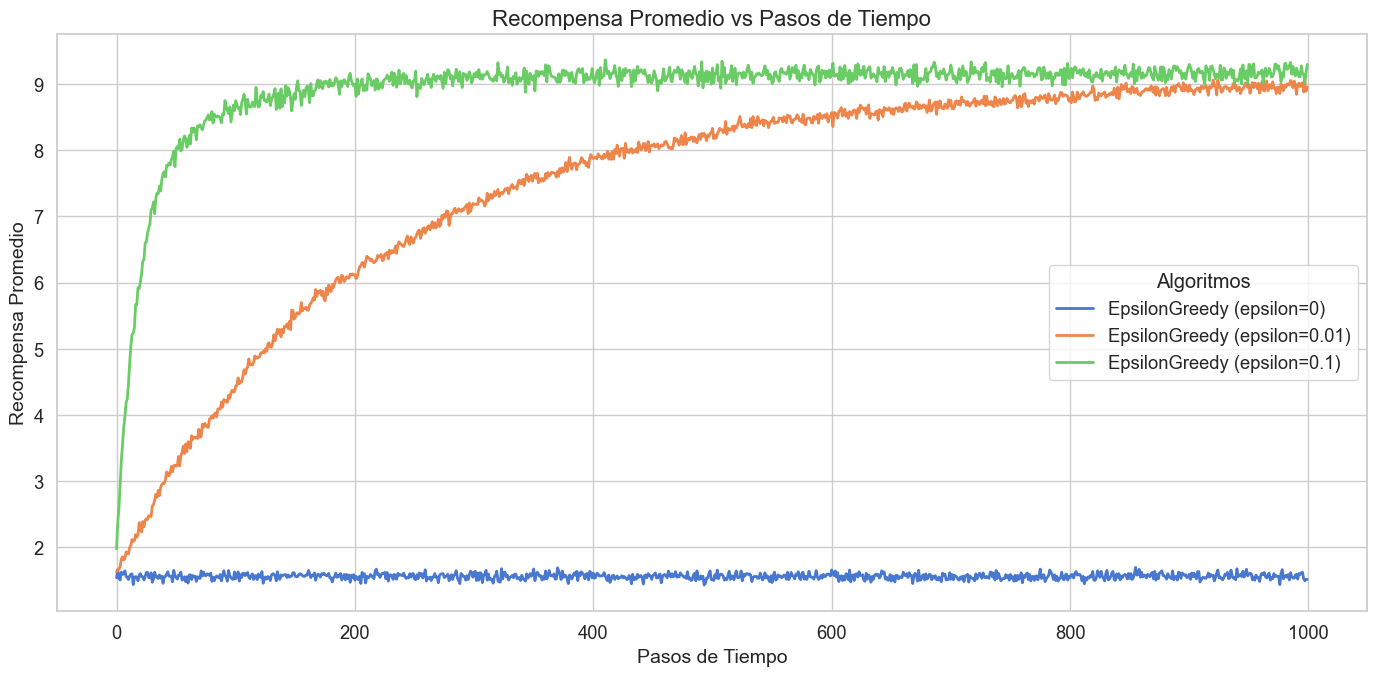

In [7]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)  # Recompensa promedio a lo largo del tiempo

#### Análisis de las gráficas

La imagen muestra un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada algoritmo.


1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - **Azul (ε = 0):** Representa una estrategia completamente **explotadora**, es decir, que siempre elige la acción que ha dado la mejor recompensa hasta ahora sin explorar nuevas opciones.
   - **Naranja (ε = 0.01):** Representa una estrategia con una pequeña probabilidad del 1% de elegir una acción aleatoria (exploración).
   - **Verde (ε = 0.1):** Representa una estrategia con un 10% de probabilidad de explorar acciones aleatorias.

2. **Crecimiento de la recompensa promedio:**
   - La línea **verde (ε=0.1)** alcanza rápidamente una recompensa promedio alta, lo que indica que la estrategia con mayor exploración aprende más rápido qué brazos del bandit son óptimos.
   - La línea **naranja (ε=0.01)** también muestra un crecimiento, pero más lento en comparación con ε=0.1.
   - La línea **azul (ε=0)** se mantiene en un nivel bajo de recompensa, lo que sugiere que no logra encontrar el mejor brazo porque no explora nuevas opciones.







### Porcentaje de Selección del Brazo Óptimo vs Pasos de Tiempo.
Esta métrica indica cuántas veces los algoritmos seleccionan el mejor brazo disponible.

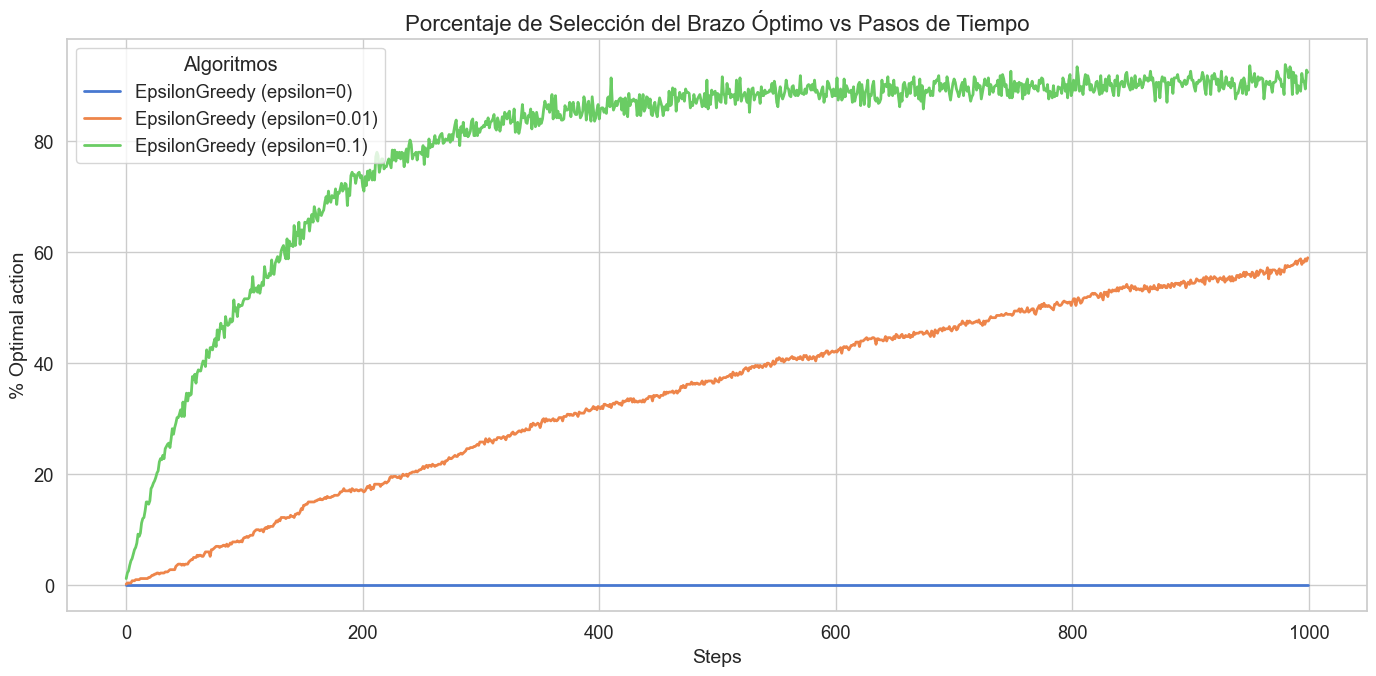

In [8]:
# Graficar la selección del brazo óptimo a lo largo del tiempo
plot_optimal_selections(steps, optimal_selections, algorithms)


#### Análisis de las gráficas

- **Epsilon = 0 (trazo azul)**: Mantiene una línea plana cercana al 0% durante toda la ejecución. Esto confirma que, sin exploración, el algoritmo no logra encontrar el brazo óptimo si no lo selecciona desde el inicio. Es el peor rendimiento en términos de selección óptima.

- **Epsilon = 0.01 (trazo rojo)**: Muestra una tendencia ascendente constante pero muy lenta. Con una exploración muy baja, el algoritmo va descubriendo el brazo óptimo, pero lo hace de forma gradual. Llega aproximadamente al 60% al final del tiempo, lo cual es mejor que no explorar, pero no tan eficiente.

- **Epsilon = 0.1 (trazo verde)**: Tiene un crecimiento rápido al inicio, alcanzando alrededor del 80% de selección óptima relativamente pronto, y se mantiene estable con algunas oscilaciones menores. La exploración más alta al principio permite encontrar rápidamente el brazo óptimo y explotarlo de manera consistente.

En resumen:
- **Más exploración al inicio (ε=0.1)** mejora significativamente el rendimiento a largo plazo.
- **Menos exploración (ε=0.01)** mejora lentamente.
- **Sin exploración (ε=0)** no logra encontrar el brazo óptimo.

La gráfica confirma lo esperado teóricamente en el dilema exploración-explotación de los multi-armed bandits. 

### Estadísticas de cada brazo

Cada valor en el eje X representará un brazo. En el eje Y se representa el promedio de las ganancias de cada brazo. El gráfico mostrará un histograma para cada brazo donde se muestre el promedio de las ganancias obtenidas pero en el eje X, como etiqueta, se mostrará también el número de veces que fue seleccionado el brazo e indicar si es el brazo óptimo o no (estrella dorada).

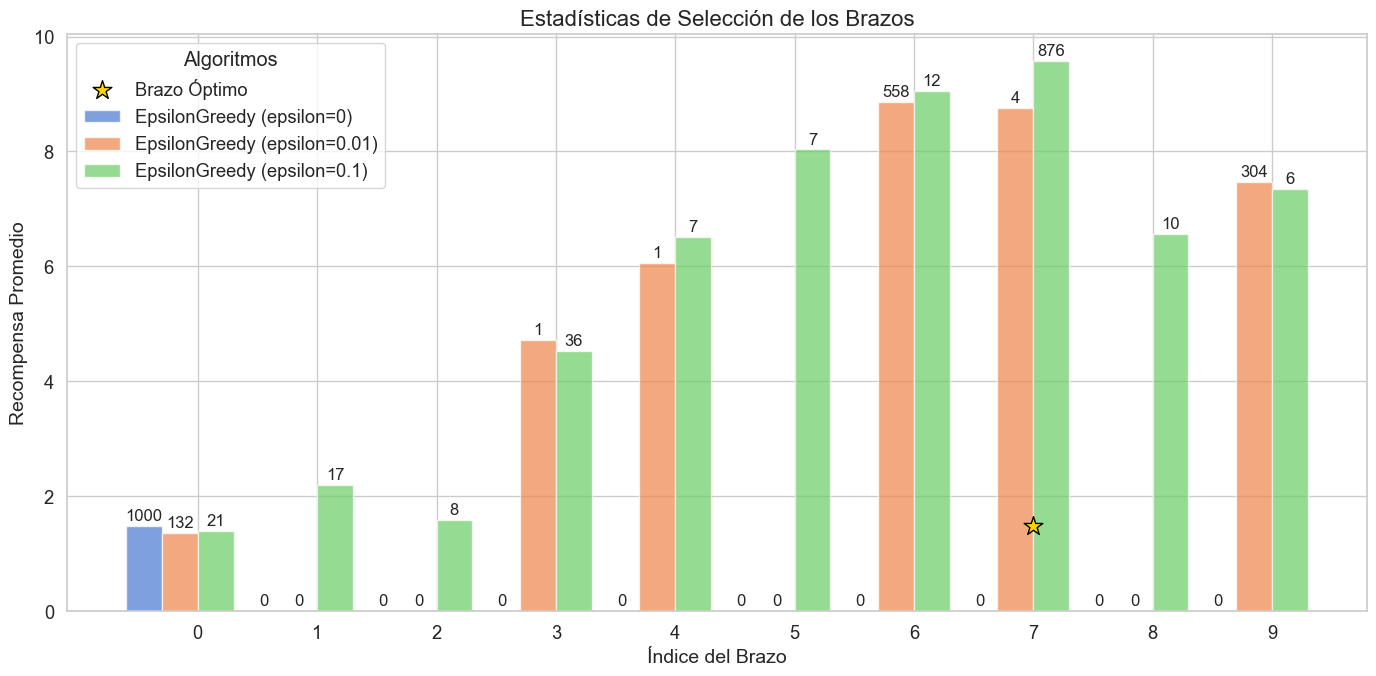

In [9]:
# Preparar los datos para la gráfica de estadísticas de brazos
arm_stats = []
for algo in algorithms:
    stats = {
        "means": algo.values,  # Recompensa promedio estimada por cada brazo
        "counts": algo.counts   # Número de veces que se seleccionó cada brazo
    }
    arm_stats.append(stats)

# Graficar estadísticas de los brazos, pasando el índice del brazo óptimo
plot_arm_statistics(arm_stats, algorithms, optimal_arm)


#### Análisis de las gráficas



**Análisis por Algoritmo**

1. **EpsilonGreedy (ε=0)**
   - El brazo 0 fue seleccionado **1000 veces** y tiene una recompensa promedio de **1.49**.
   - Todos los demás brazos **nunca fueron seleccionados** (0 selecciones, 0 recompensa promedio).
   - Esto confirma que el algoritmo *Epsilon-Greedy con ε=0* se comporta como una política *greedy* pura: **se queda atrapado en la primera acción que parece óptima** y nunca explora otras opciones.

2. **EpsilonGreedy (ε=0.01)**
   - El brazo 6 fue el más elegido con **558 selecciones** y tiene la mayor recompensa promedio (**8.87**).
   - El brazo 9 también fue seleccionado con **304 veces** y una recompensa promedio de **7.47**.
   - Algunos otros brazos se exploraron ligeramente, como el brazo 3 y 4, pero con **muy pocas selecciones (1 vez cada uno)**.
   - La exploración es mínima, lo que significa que si encuentra un brazo con una buena recompensa temprana, se queda con él la mayor parte del tiempo.

3. **EpsilonGreedy (ε=0.1)**
   - El brazo 7 fue seleccionado la mayoría de las veces (**876 selecciones**) y tiene la recompensa más alta (**9.57**).
   - Se observa una distribución más uniforme en la exploración: casi todos los brazos fueron elegidos al menos unas cuantas veces.
   - Sin embargo, la tendencia general muestra que el algoritmo converge a los mejores brazos, en este caso los brazos 7 y 6.
   - Los brazos con bajas recompensas (como 0, 1 y 2) fueron explorados pero descartados relativamente rápido.



**Resumen**
- **ε=0:** Explora **cero veces**, lo que significa que se puede quedar atrapado en una **mala decisión inicial**.
- **ε=0.01:** Explora **muy poco**, pero lo suficiente para cambiar de una mala elección inicial si encuentra una opción claramente mejor.
- **ε=0.1:** Explora **bastante más**, lo que le permite encontrar la mejor opción (brazo 7 en este caso) y explotarla de manera más eficiente.

La exploración con **ε=0.1** parece la mejor opción en este experimento, ya que descubre el brazo con la mayor recompensa promedio (9.57) y lo selecciona la mayor parte del tiempo.



### Evolución del rechazo

Muestra la evolución del rechazo, de forma análoga a cómo se muestra la evolución de las recompensas.

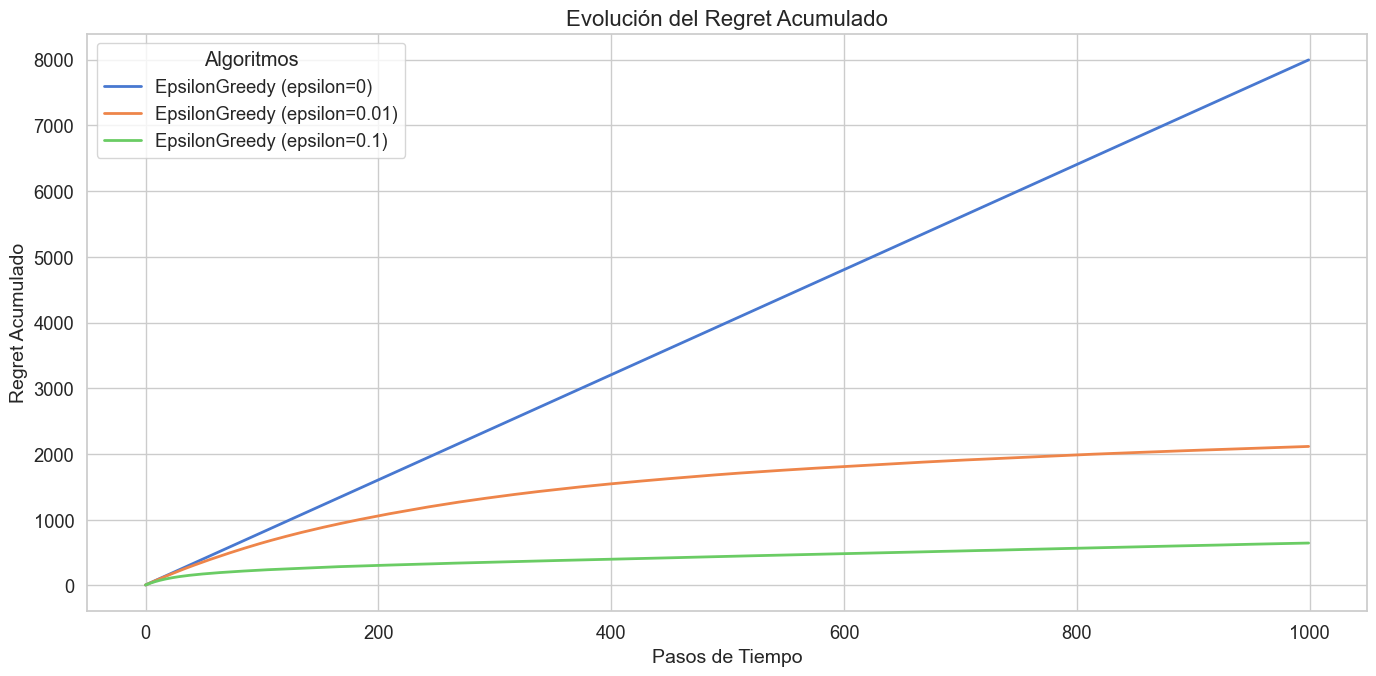

In [10]:
# Calcular el regret acumulado
optimal_reward = bandit.get_expected_value(optimal_arm)
regret_accumulated = np.cumsum(optimal_reward - rewards, axis=1)  # Regret acumulado por algoritmo

# Graficar la evolución del regret acumulado
plot_regret(steps, regret_accumulated, algorithms)

#### Análisis de las gráficas



Análisis de la evolución del **regret acumulado** en función del tiempo:

El regret acumulado mide la diferencia entre la recompensa esperada si siempre se eligiera el mejor brazo y la recompensa realmente obtenida por cada algoritmo. En otras palabras, cuanto mayor sea el regret, peor ha sido la estrategia en términos de "oportunidad perdida".

**Comparación de los algoritmos**

a) **EpsilonGreedy (epsilon=0) - Línea azul**
   - Este algoritmo no explora en absoluto, por lo que si empieza con una mala estimación del mejor brazo, se quedará atrapado en una mala decisión.
   - Su regret acumulado crece de manera lineal, lo que indica que nunca corrige su decisión inicial.
   - A los 1000 pasos, su regret es el mayor, alcanzando más de 7800.

b) **EpsilonGreedy (epsilon=0.01) - Línea naranja**
   - Explora ocasionalmente (1% del tiempo), lo que le permite encontrar un mejor brazo con el tiempo.
   - Su regret acumulado crece más lentamente que el de epsilon=0, pero sigue siendo significativo.
   - Se estabiliza en torno a los 2100 en los últimos pasos, mostrando que ha encontrado un buen brazo, pero la exploración limitada le ha costado más tiempo.

c) **EpsilonGreedy (epsilon=0.1) - Línea verde**
   - Este algoritmo explora el 10% del tiempo, lo que le permite encontrar rápidamente el mejor brazo.
   - Su regret acumulado es el más bajo, alcanzando solo ~640 en los últimos pasos.
   - Se estabiliza rápidamente, indicando que está jugando casi siempre con el mejor brazo después de un tiempo.




La estrategia Epsilon-Greedy con ε = 0.1 logra el mejor equilibrio entre exploración y explotación. Aunque ε = 0.01 mejora sobre la versión totalmente greedy, su convergencia es más lenta. En cambio, ε = 0.1 logra maximizar la recompensa y minimizar el regret, demostrando ser la mejor opción en este experimento.

## Gráficas más Relevantes y su Importancia  

Las dos gráficas siguientes son las que se consideran más relevantes:

1. **Porcentaje de Selección del Brazo Óptimo**  
   - Motivo: Permite evaluar qué tan rápido cada estrategia converge hacia la mejor opción.  
   - Relevancia: Es clave para determinar la eficiencia de cada valor de ε en encontrar y explotar la mejor acción.  
   - Hallazgo: ε = 0.1 llega al 80%+ de selecciones óptimas, lo que muestra un buen balance entre exploración y explotación.  

2. **Regret Acumulado**  
   - Motivo: Mide la pérdida de recompensa al tomar decisiones subóptimas.  
   - Relevancia: Nos permite cuantificar cuánto impactan las elecciones incorrectas a lo largo del tiempo.  
   - Hallazgo: ε = 0.1 minimiza el regret, lo que confirma que encuentra el brazo óptimo rápidamente y lo sigue explotando.  

Si la primera gráfica es alta, significa que el algoritmo elige bien. Si la segunda gráfica es baja, significa que el algoritmo pierde poco rendimiento. Juntas, estas dos gráficas explican casi todo el desempeño de los algoritmos. En los demás estudios usaremos solo estas dos gráficas